c:\Users\Maciej\Documents\GitHub\SemanticPullbacks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Maciej\Documents\GitHub\SemanticPullbacks\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Maciej\Documents\GitHub\SemanticPullbacks\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


tensor(-1., device='cuda:0') tensor(1., device='cuda:0') tensor(-0.1974, device='cuda:0') tensor(0.5294, device='cuda:0')
images.shape = torch.Size([10, 3, 224, 224])
labels = [4, 5, 7, 2, 9, 0, 0, 0, 8, 2]


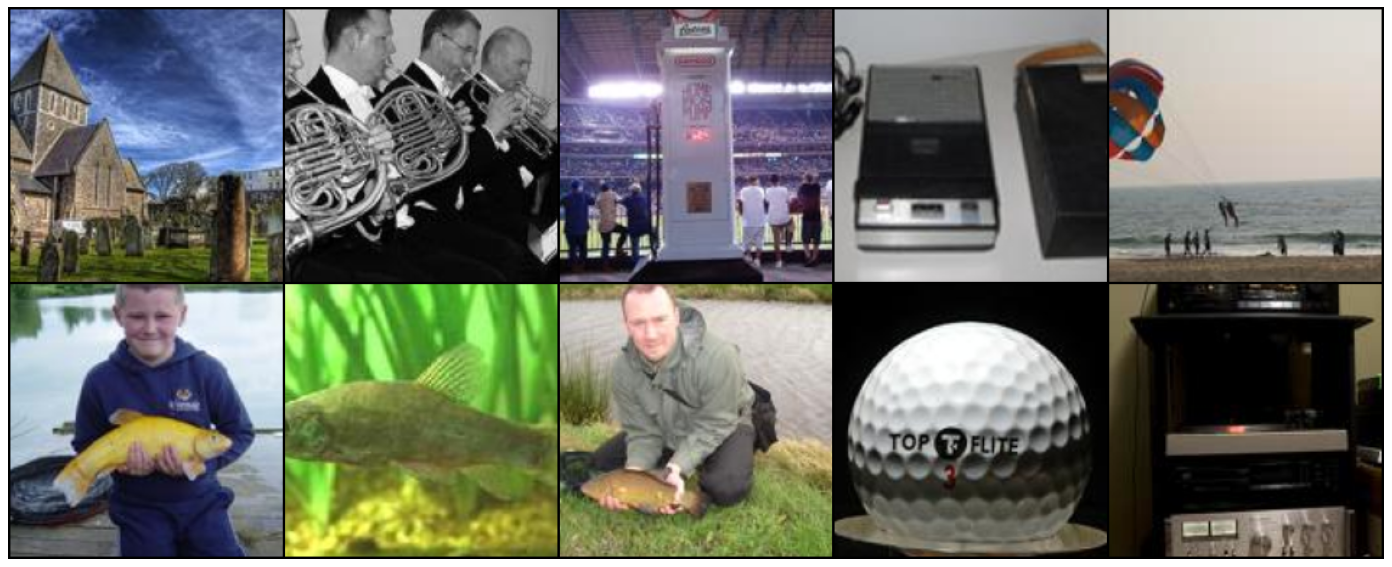

In [3]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
while 'notebooks' in os.getcwd():
    os.chdir("../")

# !pwd

import torch
from torch import nn, einsum

import gc
import torch.nn.functional as F

from lib.helpers import plot_example_grid
from lib.attributions import GradientAscentDiff, PullbackAscentDiff
from lib.faithfulness import evaluate_response_faithfulness
from lib.setup import setup_notebook
from lib.defaults import get_default_kwargs

from lib.surrogates import LayerNorm2d, PVTAttention


batch_size = 10
model_name = "resnet18"
# model_name = "resnet50"
# model_name = "vgg11_bn"
# model_name = "pvt_v2_b2"
model_source = "torchvision"
# model_source = "timm"

device, loader, model = setup_notebook(batch_size=batch_size, model_name=model_name, model_source=model_source)

it = iter(loader)
images, labels = next(it)

images = images.to(device)
labels = labels.to(device)

# print(len(loader.dataset))
print(images.min(), images.max(), images.mean(), images.std())
print(f"images.shape = {images.shape}")
print(f"labels = {labels[:10].tolist()}")

plot_example_grid(images[:10], nrow=5)

In [4]:
temperatures, pga_kwargs_multi, pga_kwargs_grad, pga_kwargs_adv = get_default_kwargs()

temperatures.update({
    nn.ReLU: 0.3,
    nn.SiLU: 1.6,
    nn.GELU: 1.0,
    nn.MaxPool2d: 0.3,
    PVTAttention: 1.5,
})
pga_kwargs_multi.update({
    "alpha": 20,
    "steps": 10,
})

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True

gad = GradientAscentDiff(model, **pga_kwargs_multi)
gad_adv = GradientAscentDiff(model, **pga_kwargs_adv)
gradient = GradientAscentDiff(model, **pga_kwargs_grad)

pad = PullbackAscentDiff(model, temperatures=temperatures, **pga_kwargs_multi)
soft_pullback = PullbackAscentDiff(model, temperatures=temperatures, **pga_kwargs_grad)

pad.atk

Attack mode is changed to 'targeted(label)'.
Attack mode is changed to 'targeted(label)'.
Attack mode is changed to 'targeted(label)'.
Attack mode is changed to 'targeted(label)'.
Attack mode is changed to 'targeted(label)'.


PGA(model_name=Sequential, device=cuda:0, attack_mode=targeted(label), targeted=True, normalization_used=False, eps=None, alpha=20, steps=10, normalize_step=True, clip_margin=0.0, clip_min=-1.0, clip_max=1.0, eps_for_division=1e-20, use_cross_entropy_loss=False, ce_loss=CrossEntropyLoss(), pnorm=2, relative_alpha=False, self_explain=False)

In [3]:
import quantus
from quantus import Metric, explain, evaluate
import captum
# from quantus.metrics.base import Metric

In [4]:
captum.metrics

<module 'captum.metrics' from '/Users/msat/.venvs/quantus/lib/python3.14/site-packages/captum/metrics/__init__.py'>

In [5]:
quantus.MaxSensitivity().get_params

{'abs': False,
 'normalise': False,
 'return_aggregate': False,
 'aggregate_func': <function mean at 0x11118f170>,
 'normalise_func': <function quantus.functions.normalise_func.normalise_by_max(a: numpy.ndarray, normalise_axes: Sequence[int] | None = None) -> numpy.ndarray>,
 'normalise_func_kwargs': {},
 '_disable_warnings': False,
 '_display_progressbar': False,
 'a_axes': None,
 'nr_samples': 200,
 'similarity_func': <function quantus.functions.similarity_func.difference(a: <built-in function array>, b: <built-in function array>, **kwargs) -> <built-in function array>>,
 'norm_numerator': <function quantus.functions.norm_func.fro_norm(a: <built-in function array>) -> float>,
 'norm_denominator': <function quantus.functions.norm_func.fro_norm(a: <built-in function array>) -> float>,
 'perturb_func': functools.partial(<function batch_uniform_noise at 0x309a503b0>, lower_bound=0.2, upper_bound=None),
 'changed_prediction_indices_func': functools.partial(<function changed_prediction_ind

In [6]:
quantus.AVAILABLE_METRICS

{'Faithfulness': {'Faithfulness Correlation': quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation,
  'Faithfulness Estimate': quantus.metrics.faithfulness.faithfulness_estimate.FaithfulnessEstimate,
  'Pixel-Flipping': quantus.metrics.faithfulness.pixel_flipping.PixelFlipping,
  'Region Segmentation': quantus.metrics.faithfulness.region_perturbation.RegionPerturbation,
  'Monotonicity-Arya': quantus.metrics.faithfulness.monotonicity.Monotonicity,
  'Monotonicity-Nguyen': quantus.metrics.faithfulness.monotonicity_correlation.MonotonicityCorrelation,
  'Selectivity': quantus.metrics.faithfulness.selectivity.Selectivity,
  'SensitivityN': quantus.metrics.faithfulness.sensitivity_n.SensitivityN,
  'IROF': quantus.metrics.faithfulness.irof.IROF,
  'ROAD': quantus.metrics.faithfulness.road.ROAD,
  'Infidelity': quantus.metrics.faithfulness.infidelity.Infidelity,
  'Sufficiency': quantus.metrics.faithfulness.sufficiency.Sufficiency},
 'Robustness': {'Continuity Test'

In [7]:
quantus.AVAILABLE_XAI_METHODS_CAPTUM

['GradientShap',
 'IntegratedGradients',
 'DeepLift',
 'DeepLiftShap',
 'InputXGradient',
 'Saliency',
 'FeatureAblation',
 'Deconvolution',
 'FeaturePermutation',
 'Lime',
 'KernelShap',
 'LRP',
 'Gradient',
 'Occlusion',
 'LayerGradCam',
 'GuidedGradCam',
 'LayerConductance',
 'LayerActivation',
 'InternalInfluence',
 'LayerGradientXActivation',
 'Control Var. Sobel Filter',
 'Control Var. Constant',
 'Control Var. Random Uniform']

In [8]:
# explanation metod:
# - create surrogate model (with temp hyperparams)
# - perform PGA toward chosen class

In [9]:
# def your_own_callable(model, inputs, targets, **kwargs) -> np.ndarray:
#   """Logic goes here to compute the attributions and return an 
#   explanation  in the same shape as x_batch (np.array), 
#   (flatten channels if necessary)."""
#   return explanation(model, inputs, targets)

# scores = metric(
#     model=model,
#     x_batch=x_batch,
#     y_batch=y_batch,
#     device=device,
#     explain_func=your_own_callable
# )